# Определение качества красного вина с помощью SVM

Мини-проект по подбору ядерных функций для классификации качества вина.  
Задача: превратить исходную оценку `quality` в бинарную категорию и подобрать лучший вариант `SVC` по метрике `accuracy`.

**Классы:**
- `bad wine` — `quality < 6.5`
- `good wine` — `quality > 6.5`

## 1. Импорт библиотек и настройки

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)

## 2. Загрузка данных

In [2]:
df = pd.read_csv(Path('..') / 'data' / 'winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.info()

Размер датасета: 1599 строк, 12 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 3. Первичный анализ качества данных

Проверим пропуски, дубликаты, типы данных и основные статистики.

In [4]:
quality_overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique()
})
quality_overview

,dtype,missing_values,missing_percent,unique_values
fixed acidity,float64,0,0.0,96
volatile acidity,float64,0,0.0,143
citric acid,float64,0,0.0,80
residual sugar,float64,0,0.0,91
chlorides,float64,0,0.0,153
free sulfur dioxide,float64,0,0.0,60
total sulfur dioxide,float64,0,0.0,144
density,float64,0,0.0,436
pH,float64,0,0.0,89
sulphates,float64,0,0.0,96


In [5]:
print(f'Количество полных дубликатов: {df.duplicated().sum()}')
df.describe().T.round(3)

Количество полных дубликатов: 240


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


Оставим дубликаты, чтобы изменения не отразились на распределении классов

## 4. Распределение исходной целевой переменной

Посмотрим, как распределены исходные оценки качества вина от 3 до 8.

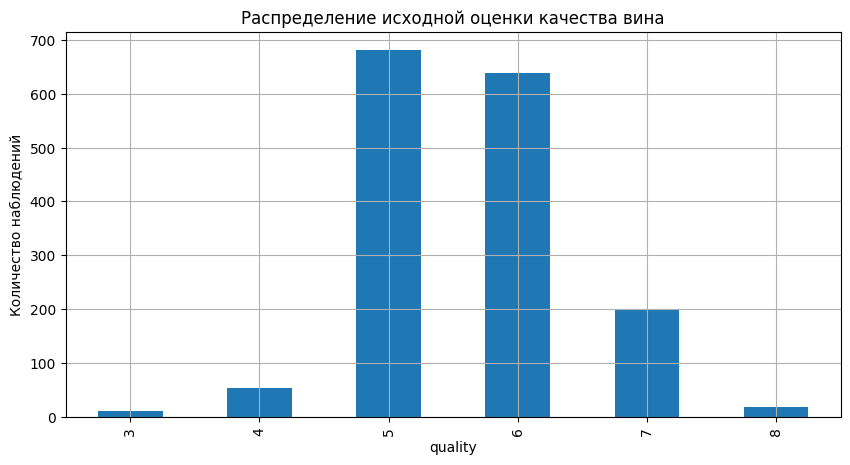

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [6]:
quality_counts = df['quality'].value_counts().sort_index()

ax = quality_counts.plot(kind='bar')
ax.set_title('Распределение исходной оценки качества вина')
ax.set_xlabel('quality')
ax.set_ylabel('Количество наблюдений')
plt.show()

quality_counts.to_frame('count')

Основная масса наблюдений имеет оценки 5 и 6. Вин с оценками 7 и 8 существенно меньше, поэтому после бинаризации появится дисбаланс классов.

## 5. Распределения признаков

Посмотрим на гистограммы всех числовых признаков, чтобы увидеть асимметрию, выбросы и различия масштабов.

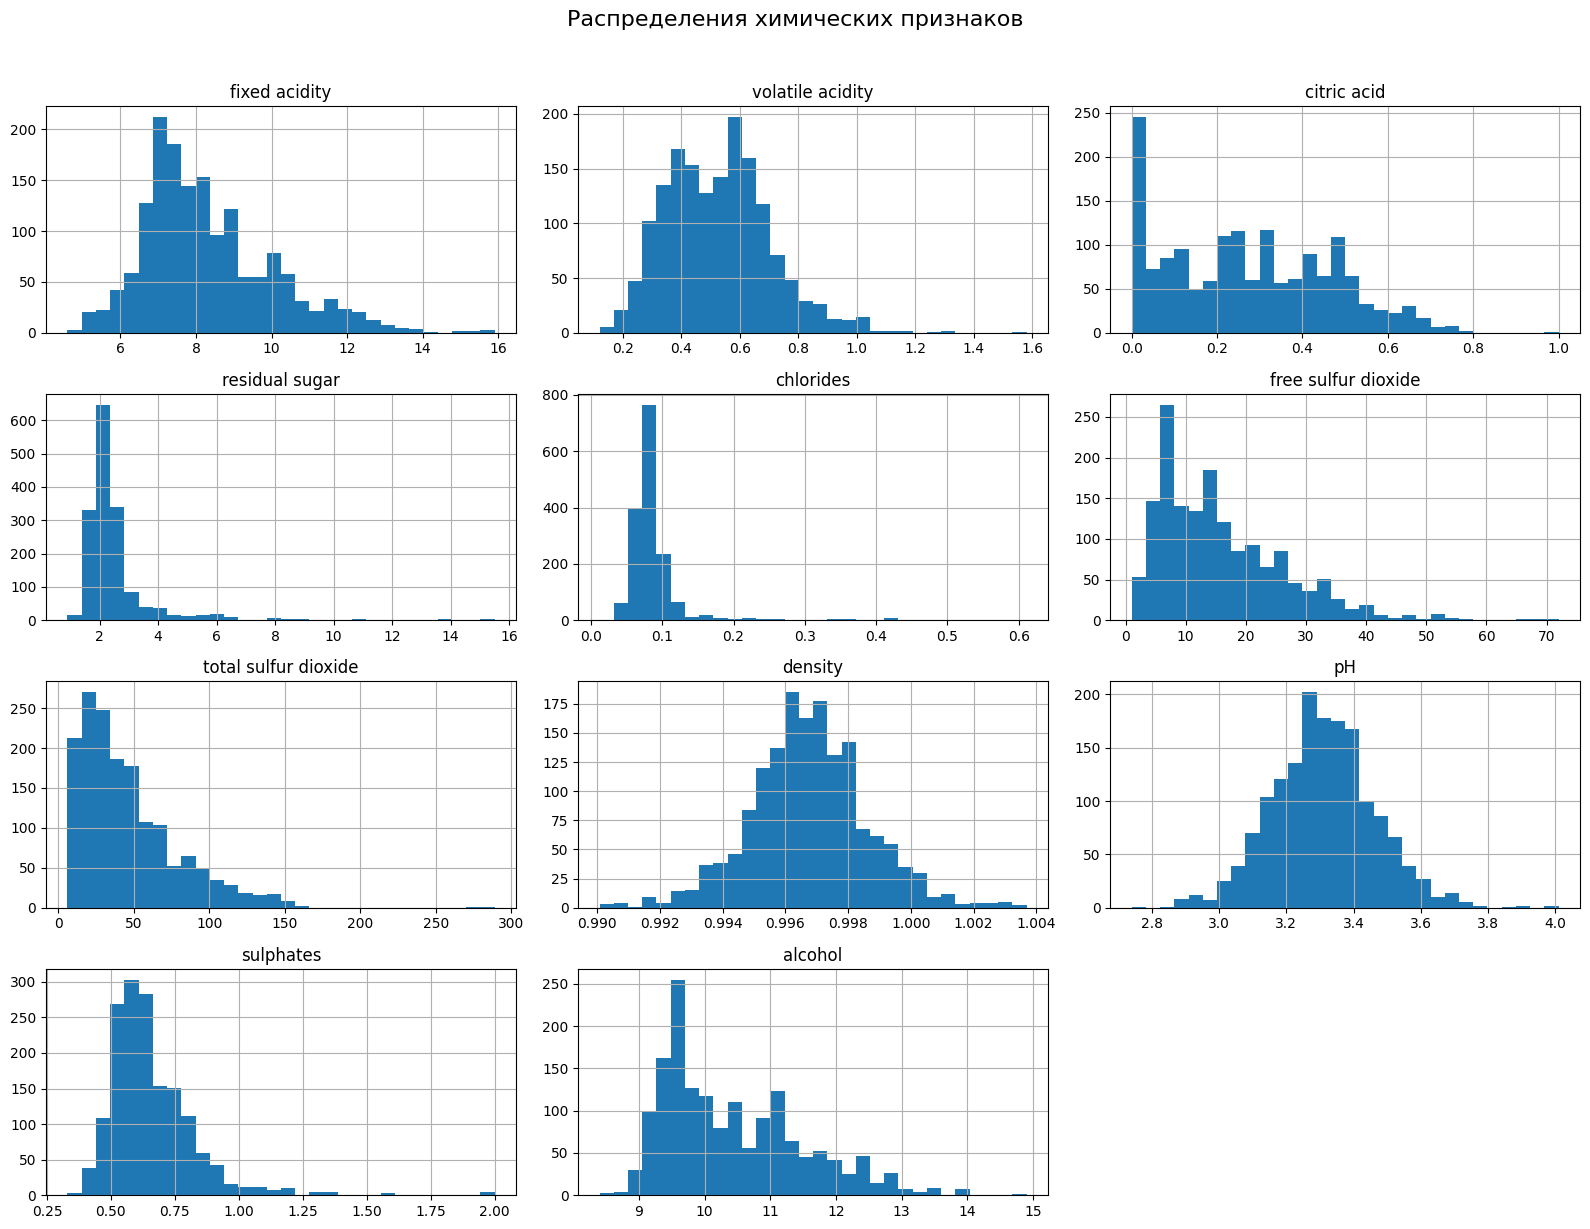

In [7]:
feature_cols = df.drop(columns='quality').columns

axes = df[feature_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle('Распределения химических признаков', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
skewness = df[feature_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
skewness.to_frame('skewness').round(3)

,skewness
chlorides,5.680
residual sugar,4.541
sulphates,2.429
total sulfur dioxide,1.516
free sulfur dioxide,1.251
fixed acidity,0.983
alcohol,0.861
volatile acidity,0.672
citric acid,0.318
pH,0.194


Многие признаки имеют правостороннюю асимметрию: например, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide` и `sulphates`. Для SVM особенно важен масштаб признаков, поэтому далее используем `StandardScaler` внутри `Pipeline`.

## 6. Корреляция признаков с качеством

Оценим линейную связь между химическими показателями и исходной оценкой качества.

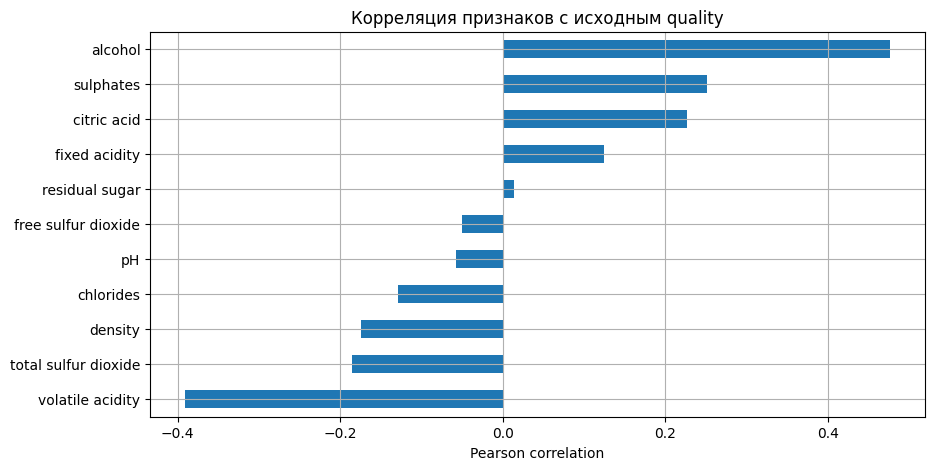

,correlation_with_quality
alcohol,0.476
volatile acidity,-0.391
sulphates,0.251
citric acid,0.226
total sulfur dioxide,-0.185
density,-0.175
chlorides,-0.129
fixed acidity,0.124
pH,-0.058
free sulfur dioxide,-0.051


In [9]:
corr_with_quality = (
    df.corr(numeric_only=True)['quality']
      .drop('quality')
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

ax = corr_with_quality.sort_values().plot(kind='barh')
ax.set_title('Корреляция признаков с исходным quality')
ax.set_xlabel('Pearson correlation')
plt.show()

corr_with_quality.to_frame('correlation_with_quality').round(3)

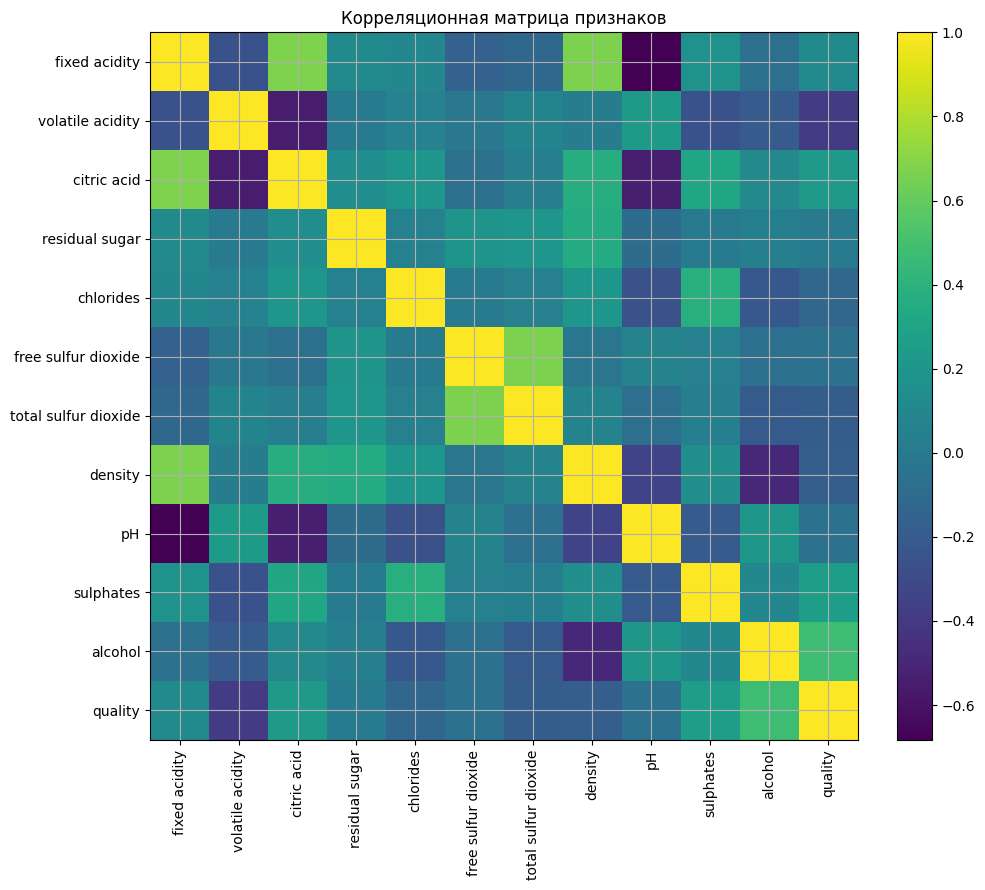

In [10]:
fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = df.corr(numeric_only=True)
im = ax.imshow(corr_matrix)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
ax.set_title('Корреляционная матрица признаков')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Наиболее заметные связи с качеством имеют `alcohol`, `volatile acidity`, `sulphates` и `citric acid`. Знак корреляции интерпретируем: более высокий алкоголь и сульфаты чаще связаны с лучшей оценкой, а высокая летучая кислотность — с худшей.

## 7. Категоризация и кодирование таргета

Создадим бинарную целевую переменную по условию задания и закодируем её числами.

In [11]:
df_model = df.copy()
df_model['wine_category'] = np.where(df_model['quality'] < 6.5, 'bad wine', 'good wine')

label_encoder = LabelEncoder()
df_model['target'] = label_encoder.fit_transform(df_model['wine_category'])

class_mapping = {
    label: int(code)
    for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
}
print('Кодирование классов:', class_mapping)

df_model[['quality', 'wine_category', 'target']].head(10)

Кодирование классов: {'bad wine': 0, 'good wine': 1}


,quality,wine_category,target
0,5,bad wine,0
1,5,bad wine,0
2,5,bad wine,0
3,6,bad wine,0
4,5,bad wine,0
5,5,bad wine,0
6,5,bad wine,0
7,7,good wine,1
8,7,good wine,1
9,5,bad wine,0


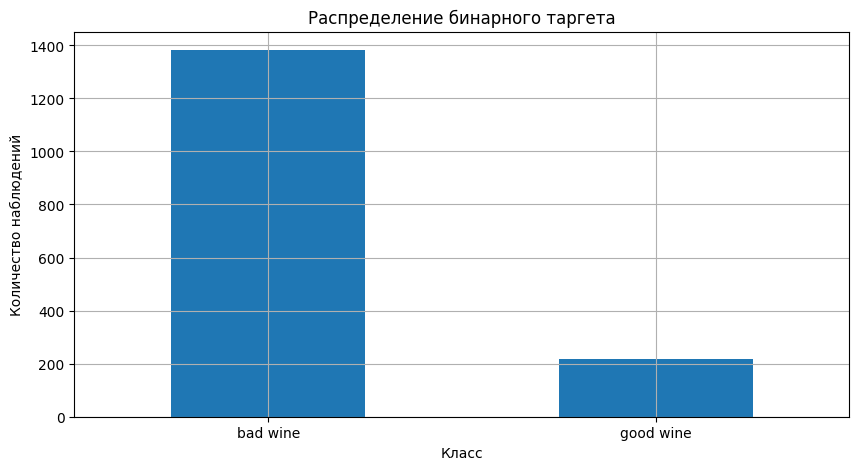

,count,share
wine_category,,
bad wine,1382,0.864
good wine,217,0.136


In [12]:
class_counts = df_model['wine_category'].value_counts()

ax = class_counts.plot(kind='bar')
ax.set_title('Распределение бинарного таргета')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество наблюдений')
plt.xticks(rotation=0)
plt.show()

pd.DataFrame({
    'count': class_counts,
    'share': (class_counts / len(df_model)).round(3)
})

Класс `bad wine` доминирует. Поэтому кроме accuracy полезно смотреть confusion matrix и classification report, чтобы видеть качество распознавания меньшего класса `good wine`.

## 8. Feature engineering

Добавим несколько простых химически интерпретируемых признаков

In [13]:
eps = 1e-6

# Соотношение свободного и общего SO2: доля свободного диоксида серы.
df_model['free_so2_ratio'] = df_model['free sulfur dioxide'] / (df_model['total sulfur dioxide'] + eps)

# Условный индекс кислотности: фиксированная кислота относительно pH.
df_model['acidity_ph_ratio'] = df_model['fixed acidity'] / (df_model['pH'] + eps)

# Баланс лимонной и летучей кислотности.
df_model['citric_volatile_ratio'] = df_model['citric acid'] / (df_model['volatile acidity'] + eps)

# Сахар на единицу алкоголя.
df_model['sugar_alcohol_ratio'] = df_model['residual sugar'] / (df_model['alcohol'] + eps)

new_features = ['free_so2_ratio', 'acidity_ph_ratio', 'citric_volatile_ratio', 'sugar_alcohol_ratio']
df_model[new_features].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
free_so2_ratio,1599.0,0.382,0.155,0.023,0.259,0.375,0.485,0.857
acidity_ph_ratio,1599.0,2.535,0.624,1.179,2.093,2.411,2.857,5.342
citric_volatile_ratio,1599.0,0.668,0.619,0.000,0.152,0.483,1.082,4.000
sugar_alcohol_ratio,1599.0,0.246,0.142,0.071,0.183,0.211,0.255,1.711


## 9. Train/test split

Сделаем стратифицированное разбиение, чтобы сохранить соотношение классов в обучающей и тестовой выборках.

In [14]:
X = df_model.drop(columns=['quality', 'wine_category', 'target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train target distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))

Train shape: (1279, 15)
Test shape: (320, 15)
Train target distribution:
target
0    0.864
1    0.136
Name: proportion, dtype: float64


## 10. Baseline-модель

Перед подбором SVM зафиксируем простой baseline: всегда предсказывать самый частый класс. Это важно из-за дисбаланса классов.

In [15]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f'Baseline test accuracy: {baseline_accuracy:.4f}')
baseline_class = int(pd.Series(baseline_pred).mode()[0])
print('Baseline prediction class:', label_encoder.inverse_transform([baseline_class])[0])

Baseline test accuracy: 0.8656
Baseline prediction class: bad wine


## 11. Подбор гиперпараметров SVC

Используем `Pipeline`, чтобы масштабирование выполнялось внутри кросс-валидации и не было утечки данных. Подбираем:
- `kernel`: `linear`, `poly`, `rbf`, `sigmoid`
- `C`: сила регуляризации
- `gamma`: коэффициент ядра
- `degree`: степень полинома для `poly`

Основная метрика — `accuracy`, поэтому финальная модель выбирается именно по ней.

In [16]:
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=RANDOM_STATE))
])

param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10]
    },
    {
        'svc__kernel': ['rbf', 'sigmoid'],
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 0.01, 0.1]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 0.01, 0.1],
        'svc__degree': [2, 3]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=1,
    verbose=0,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print('Лучшие параметры:')
print(grid_search.best_params_)
print(f"Лучший mean CV accuracy на train: {grid_search.best_score_:.4f}")

Лучшие параметры:
{'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Лучший mean CV accuracy на train: 0.8898


In [17]:
results = pd.DataFrame(grid_search.cv_results_)
results['kernel'] = results['param_svc__kernel'].astype(str)

cols = [
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'mean_train_score', 'param_svc__kernel', 'param_svc__C',
    'param_svc__gamma', 'param_svc__degree'
]

top_results = (
    results[cols]
    .sort_values('rank_test_score')
    .head(12)
    .reset_index(drop=True)
)

top_results.round(4)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_svc__kernel,param_svc__C,param_svc__gamma,param_svc__degree
0,1,0.8898,0.0120,0.9705,rbf,10.0,0.1,NaN
1,2,0.8890,0.0130,0.9519,rbf,10.0,scale,NaN
2,3,0.8890,0.0092,0.9120,rbf,1.0,0.1,NaN
3,4,0.8866,0.0051,0.9425,poly,10.0,scale,3.0
4,5,0.8843,0.0094,0.9261,poly,1.0,0.1,3.0
5,6,0.8819,0.0126,0.9011,rbf,1.0,scale,NaN
6,7,0.8796,0.0063,0.9547,poly,10.0,0.1,3.0
7,8,0.8733,0.0107,0.9073,poly,1.0,scale,3.0
8,9,0.8718,0.0152,0.9005,poly,10.0,0.1,2.0
9,10,0.8655,0.0102,0.8931,poly,10.0,scale,2.0


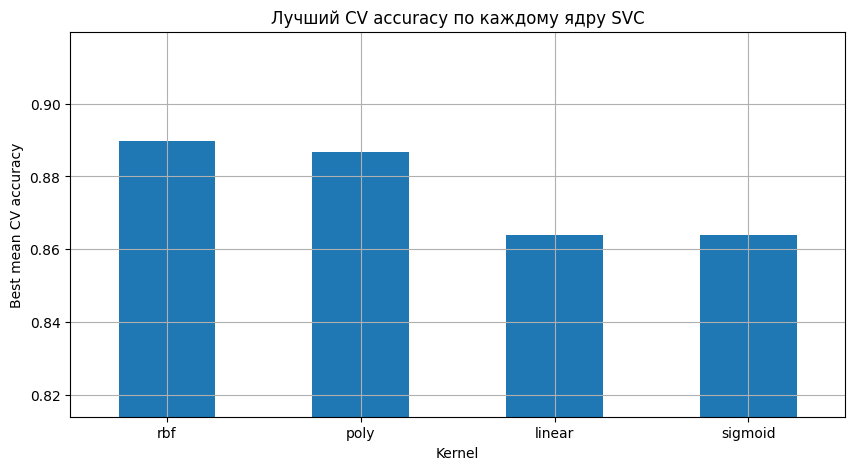

,max,mean,std
kernel,,,
rbf,0.8898,0.8745,0.0125
poly,0.8866,0.8674,0.0084
linear,0.8640,0.8640,0.0000
sigmoid,0.8640,0.8441,0.0185


In [18]:
kernel_summary = (
    results.groupby('kernel')['mean_test_score']
    .agg(['max', 'mean', 'std'])
    .sort_values('max', ascending=False)
)

ax = kernel_summary['max'].plot(kind='bar')
ax.set_title('Лучший CV accuracy по каждому ядру SVC')
ax.set_xlabel('Kernel')
ax.set_ylabel('Best mean CV accuracy')
plt.xticks(rotation=0)
plt.ylim(max(0, kernel_summary['max'].min() - 0.05), min(1, kernel_summary['max'].max() + 0.03))
plt.show()

kernel_summary.round(4)

Лучшее ядро выбирается по результатам `GridSearchCV`. В текущем запуске лучший результат даёт `rbf`-ядро.

## 12. Оценка лучшей модели на тестовой выборке

Проверим модель на отложенной тестовой выборке, которая не участвовала в подборе гиперпараметров.

In [19]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Improvement over baseline: {test_accuracy - baseline_accuracy:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Test accuracy: 0.9156
Improvement over baseline: 0.0500

Classification report:
              precision    recall  f1-score   support

    bad wine       0.94      0.96      0.95       277
   good wine       0.72      0.60      0.66        43

    accuracy                           0.92       320
   macro avg       0.83      0.78      0.81       320
weighted avg       0.91      0.92      0.91       320



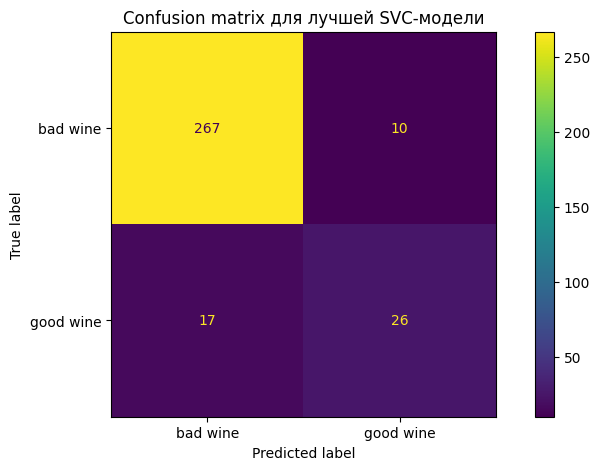

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(values_format='d')
plt.title('Confusion matrix для лучшей SVC-модели')
plt.grid(False)
plt.show()

## 13. Финальная кросс-валидация лучшей модели

Переоценим найденную конфигурацию на всём датасете с 5-fold stratified CV.

In [21]:
final_cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy', n_jobs=1)

print('CV scores:', np.round(final_cv_scores, 4))
print(f'Mean CV accuracy: {final_cv_scores.mean():.4f}')
print(f'Std CV accuracy:  {final_cv_scores.std():.4f}')

CV scores: [0.8969 0.9125 0.9156 0.8719 0.9185]
Mean CV accuracy: 0.9031
Std CV accuracy:  0.0173


## 14. Выводы

1. Исходный таргет `quality` был преобразован в бинарную категорию: `bad wine` и `good wine`.
2. В данных есть заметный дисбаланс: класс `good wine` существенно меньше класса `bad wine`.
3. Признаки имеют разные масштабы, поэтому `StandardScaler` включён в `Pipeline` и применяется внутри кросс-валидации.
4. Для выбора ядра использован `GridSearchCV` по `linear`, `poly`, `rbf` и `sigmoid`.
5. По метрике `accuracy` лучшим стало `rbf`-ядро с параметрами `C=10` и `gamma=0.1`.
6. Итоговая модель показала качество выше baseline, но из-за дисбаланса классов для реальной задачи дополнительно стоит анализировать `precision`, `recall`, `f1-score` и confusion matrix.